In [1]:
from wrapper import BasicEnvironmentRGB, DomainRandomization
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation, TransformObservation
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from rltesting.torch_rl.buffers import ReplayBuffer
from rltesting.torch_rl.models import MLP, TargetNetwork
from fundamental_variable_discovery import Encoder, Decoder, DoubleAutoencoder
import torch.nn.functional as F
import numpy as np
import torch
import skdim

to_numpy = lambda x: x.cpu().detach().numpy()
framestack = 2
latent_dim = 1024
obs_shape = 64
steps = 20000
l1_coeff = 0
env = gym.make('Acrobot-v1', render_mode="rgb_array")
# env = DomainRandomization(env, {"LINK_LENGTH_1": (0.5, 2.0), "LINK_LENGTH_2": (0.5, 2.0)})
env = BasicEnvironmentRGB(env, (obs_shape, obs_shape))
env = FrameStackObservation(env, stack_size=framestack)
env = TransformObservation(env, lambda obs: np.transpose(obs, (1, 2, 0, 3)), observation_space=gym.spaces.Box(0, 255, (framestack, 3, obs_shape, obs_shape), dtype=np.uint8))
env = TransformObservation(env, lambda obs: np.reshape(obs, (obs_shape, obs_shape, 3 * framestack)), observation_space=gym.spaces.Box(0, 255, (obs_shape, obs_shape, 3 * framestack), dtype=np.uint8))
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=steps)

In [2]:
# samples = random_sample_single_env(env, num_steps=steps)
# for i in range(steps):
#     buffer.add_sample([samples[j][i] for j in range(len(samples))].copy())

In [3]:
# encoder = Encoder(framestack, latent_dim, obs_shape).cuda()
# decoder = Decoder(encoder.conv_dim, framestack, latent_dim).cuda()
# opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), 3e-5)
# losses = []
# for i in range(20000):
#     if i % 1000 == 0:
#         print(i)
#     samples = buffer.sample(256)
#     obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
#     latent = encoder(obs)
#     reconstruction = decoder(latent)
#     loss = torch.nn.functional.mse_loss(reconstruction, obs)
#     loss.backward()
#     opt.step()
#     opt.zero_grad()
#     losses.append(loss.detach().cpu().numpy())
# plt.plot(losses)

In [4]:
# latent_ID = []
# image_ID = []

# for _ in range(20):
#     samples = buffer.sample(2048)
#     obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255 ).cuda()
#     latent = encoder(obs)
#     unique_latents = np.unique(latent.detach().cpu().numpy(), axis=0)
#     unique_obs = np.unique(obs.detach().cpu().numpy(), axis=0).reshape(-1, 3 * framestack*obs_shape*obs_shape)

#     latent_ID.append(skdim.id.MLE().fit(unique_latents).dimension_)
#     image_ID.append(skdim.id.MLE().fit(unique_obs).dimension_)

# print(f"Latent ID: {np.mean(latent_ID)} +- {np.std(latent_ID)}")
# print(f"Image ID: {np.mean(image_ID)} +- {np.std(image_ID)}")

In [5]:
# intrinsic_dim = round(np.mean(latent_ID))
# double_autoencoder = DoubleAutoencoder(encoder, decoder, latent_dim, intrinsic_dim).cuda()
# int_opt = torch.optim.AdamW(double_autoencoder.parameters(), 3e-5)

# losses = []
# for i in range(20000):
#     if i % 1000 == 0:
#         print(i)
#     samples = buffer.sample(256)
#     obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
#     intrinsic = double_autoencoder.double_encode(obs)
#     reconstruction = double_autoencoder.double_decode(intrinsic)
#     loss = torch.nn.functional.mse_loss(reconstruction, obs)
#     loss.backward()
#     int_opt.step()
#     int_opt.zero_grad()
#     opt.step()
#     opt.zero_grad()
#     losses.append(loss.detach().cpu().numpy())
# plt.plot(losses)

In [6]:
# torch.save(double_autoencoder, 'double_autoencoder_5d.pt')

In [9]:
intrinsic_dim = 5
double_autoencoder = torch.load('double_autoencoder_5d.pt', weights_only=False)
int_opt = torch.optim.AdamW(double_autoencoder.parameters(), 3e-5)

In [10]:
num_actions = 3
q_network = MLP(intrinsic_dim, num_actions, skip_connections=False).cuda()
q_opt = torch.optim.Adam(q_network.parameters(), 3e-4)
dtypes = [np.uint8, np.float32, np.float32, np.uint8, np.float32]
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), (obs_shape, obs_shape, 3 * framestack), ()]
dqn_buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=100_000)
q_target = TargetNetwork(q_network, tau=1e-3).cuda()
eps = 1
eps_decay = 0.95
eps_min = 0.1
num_episodes = 500
train_after = 1000
gamma = 0.99

In [11]:
def dqn_loss(q_network, q_target, obs, action, reward, next_obs, done, q_opt):
    q_target = reward + gamma * q_target(next_obs).detach().gather(1, torch.argmax(q_network(next_obs).detach(), 1, keepdim=True)).squeeze() * (1 - done)
    q_values = q_network(obs).gather(1, action.unsqueeze(-1)).squeeze()
    q_loss = F.mse_loss(q_target, q_values)
    q_opt.zero_grad()
    q_loss.backward()
    q_opt.step()
    return q_loss

def model_losses(q_network, q_target, double_autoencoder, buffer, q_opt, double_ae_opt, batch_size=512):
    q_target.update()
    obs, action, reward, next_obs, done = buffer.sample(batch_size)
    obs = (torch.tensor(obs).float().transpose(-3, -1) / 255).cuda()
    action = torch.tensor(action).long().cuda()
    reward = torch.tensor(reward).float().cuda()
    next_obs = (torch.tensor(next_obs).float().transpose(-3, -1) / 255).cuda()
    done = torch.tensor(done).float().cuda()
    intrinsic = double_autoencoder.double_encode(obs).detach()
    next_intrinsic = double_autoencoder.double_encode(next_obs).detach()
    q_target = reward + gamma * q_target(next_intrinsic).detach().gather(1, torch.argmax(q_network(next_intrinsic).detach(), 1, keepdim=True)).squeeze() * (1 - done)
    q_values = q_network(intrinsic).gather(1, action.unsqueeze(-1)).squeeze()
    q_loss = F.mse_loss(q_target, q_values)
    q_opt.zero_grad()
    q_loss.backward()
    q_opt.step()
    
    intrinsic = double_autoencoder.double_encode(obs)
    reconstruction = double_autoencoder.double_decode(intrinsic)
    reconstruction_loss = F.mse_loss(reconstruction, obs)
    double_ae_opt.zero_grad()
    reconstruction_loss.backward()
    double_ae_opt.step()
    
    return to_numpy(q_loss.cpu()), to_numpy(reconstruction_loss.cpu())

In [ ]:
ep_rews = []
q_losses = []
ae_losses = []
step = 0
ep_rew = 0
ep_rew_ema = None
for episode in range(num_episodes):
    if episode % 100 == 0:
        print(episode, ep_rew)
    obs, _ = env.reset()
    done = False
    ep_rew = 0
    q_loss_ = []
    ae_loss_ = []
    while not done:
        step += 1
        if step > train_after:
            eps = max(eps_min, eps * eps_decay)
            obs_tensor = (torch.tensor(obs).float().transpose(-3, -1) / 255).cuda()
            if np.random.rand() < eps:
                action = np.random.randint(num_actions)
            else:
                intrinsic = double_autoencoder.double_encode(obs_tensor.unsqueeze(0))
                action = to_numpy(q_network(intrinsic).argmax())
            q_loss, ae_loss = model_losses(q_network, q_target, double_autoencoder, dqn_buffer, q_opt, int_opt)
            q_loss_.append(q_loss)
            ae_loss_.append(ae_loss)
        else:
            action = env.action_space.sample()
        next_obs, reward, term, trunc, _ = env.step(action)
        done = term or trunc
        dqn_buffer.add_sample([obs, action, reward, next_obs, done])
        ep_rew += reward
        obs = next_obs
    if ep_rew_ema is None:
        ep_rew_ema = ep_rew
    else:
        ep_rew_ema = 0.9 * ep_rew_ema + ep_rew
    ep_rews.append(ep_rew)
    q_losses.append(np.mean(q_loss_))
    ae_losses.append(np.mean(ae_loss_))

0 0


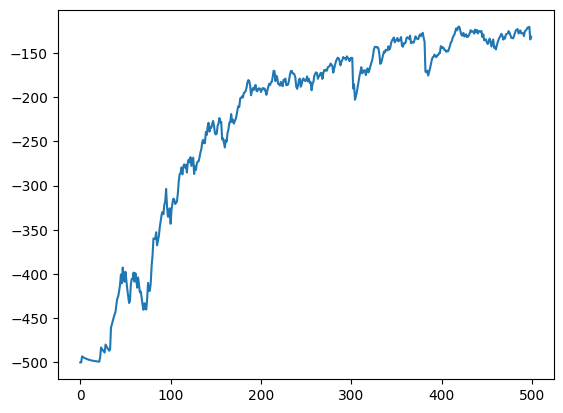

In [ ]:
smoothing = 0.9
ep_rew_ema = None
smoothed_rewards = []
for ep_rew in ep_rews:
    if ep_rew_ema is None:
        ep_rew_ema = ep_rew
    else:
        ep_rew_ema = smoothing * ep_rew_ema + (1 - smoothing) * ep_rew
    smoothed_rewards.append(ep_rew_ema)
plt.plot(smoothed_rewards)
plt.savefig("smoothed_ep_rew.png")
np.save("smoothed_rewards.npy", np.asarray(smoothed_rewards))

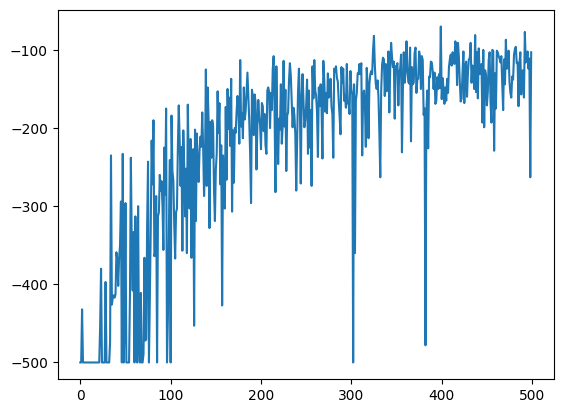

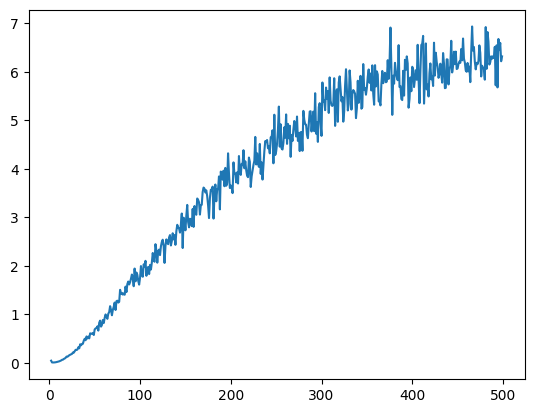

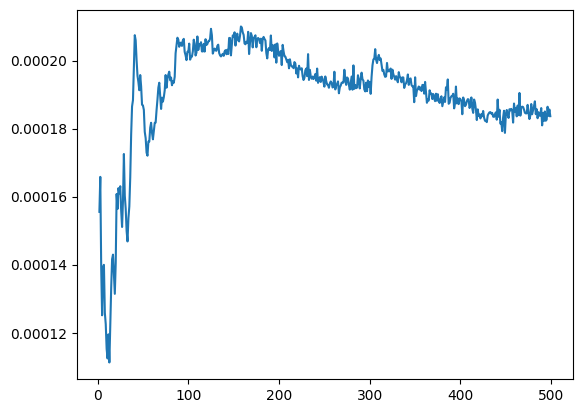

In [ ]:
plt.plot(ep_rews)
plt.savefig("ep_rew.png")
plt.show()
plt.plot(q_losses)
plt.show()
plt.plot(ae_losses)
plt.show()